In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("HR_data_2.csv")

In [7]:
df["Phase"] = df["Phase"].astype(str)
df["Round"] = df["Round"].astype(str)
df["Individual"] = df["Individual"].astype(str)
df["Cohort"] = df["Cohort"].astype(str)

# T-SNE

#1.Audit

shape
unique values
rows per phase/cohort/round
missing values
duplicates
constant columns

In [10]:
import pandas as pd
import numpy as np

if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

meta_cols = [
    "Round", "Phase", "Individual", "Puzzler",
    "original_ID", "raw_data_path", "Team_ID", "Cohort"
]

self_report_cols = [
    "Frustrated", "upset", "hostile", "alert", "ashamed",
    "inspired", "nervous", "attentive", "afraid", "active", "determined"
]

hr_cols   = [c for c in df.columns if c.startswith("HR_")]
temp_cols = [c for c in df.columns if c.startswith("TEMP_")]
eda_p_cols = [c for c in df.columns if c.startswith("EDA_TD_P_")]
eda_t_cols = [c for c in df.columns if c.startswith("EDA_TD_T_")]
feature_cols = hr_cols + temp_cols + eda_p_cols + eda_t_cols

print(f"HR:    {len(hr_cols)} features")
print(f"TEMP:  {len(temp_cols)} features")
print(f"EDA_P: {len(eda_p_cols)} features")
print(f"EDA_T: {len(eda_t_cols)} features")
print(f"Total: {len(feature_cols)} features")

print("\n--- STRUCTURE ---")
print("Shape:", df.shape)
print("Unique Individuals:", df["Individual"].nunique())
print("Unique Cohorts:", df["Cohort"].nunique())
print("Rounds:", sorted(df["Round"].unique()))
print("Phases:", sorted(df["Phase"].unique()))

print("\nRows per Phase:")
print(df["Phase"].value_counts().sort_index())

print("\nRows per Cohort:")
print(df["Cohort"].value_counts())

print("\nRows per Round:")
print(df["Round"].value_counts().sort_index())


print("\n--- BALANCE CHECK ---")
balance = df.groupby(
    ["Individual", "Round", "Phase"]
).size().reset_index(name="count")

print("Count distribution):")
print(balance["count"].value_counts())

missing_combos = balance[balance["count"] != 1]
if len(missing_combos) > 0:
    print("problems:")
    print(missing_combos)
else:
    print("unique")

#data types
phase_order = ["phase1", "phase2", "phase3"]
df["Phase"] = pd.Categorical(
    df["Phase"], categories=phase_order, ordered=True
)
df["Round"] = df["Round"].astype("category")
df["Cohort"] = df["Cohort"].astype("category")
df["Individual_str"] = df["Individual"].astype(str)



print("\n--- MISSING VALUES ---")
missing = df[feature_cols + self_report_cols].isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
if len(missing) > 0:
    print(missing)
else:
    print("no mis values")


print("\n--- PHYSIOLOGICAL RANGE CHECK ---")
print(f"HR_TD_Mean:   min={df['HR_TD_Mean'].min():.1f}, "
      f"max={df['HR_TD_Mean'].max():.1f}")
print(f"TEMP_TD_Mean: min={df['TEMP_TD_Mean'].min():.1f}, "
      f"max={df['TEMP_TD_Mean'].max():.1f}")
print(f"EDA_TD_T_Mean: min={df['EDA_TD_T_Mean'].min():.2f}, "
      f"max={df['EDA_TD_T_Mean'].max():.2f}")

print(f"\n suspicious HR:")
print(f"  HR > 120 bpm: {(df['HR_TD_Mean'] > 120).sum()} rows")
print(f"  HR < 45 bpm:  {(df['HR_TD_Mean'] < 45).sum()} rows")


print("\n--- SELF-REPORT RANGE CHECK ---")
for col in self_report_cols:
    valid_max = 10 if col == 'Frustrated' else 5
    valid_min = 0 if col == 'Frustrated' else 1
    out = ((df[col] < valid_min) | (df[col] > valid_max)).sum()
    flag = "bad" if out > 0 else "good"
    print(f"{flag} {col:12s}: min={df[col].min():.0f}, "
          f"max={df[col].max():.0f}, "
          f"out of range: {out}")


print("\n--- CLEAN FEATURE MATRIX ---")
X_df = df[feature_cols].copy()
X_df = X_df.replace([np.inf, -np.inf], np.nan)
X_df = X_df.fillna(X_df.median(numeric_only=True))


print("Clean feature shape:", X_df.shape)

HR:    12 features
TEMP:  12 features
EDA_P: 15 features
EDA_T: 12 features
Total: 51 features

--- STRUCTURE ---
Shape: (312, 71)
Unique Individuals: 26
Unique Cohorts: 6
Rounds: ['round_1', 'round_2', 'round_3', 'round_4']
Phases: ['phase1', 'phase2', 'phase3']

Rows per Phase:
Phase
phase1    104
phase2    104
phase3    104
Name: count, dtype: int64

Rows per Cohort:
Cohort
D1_1    96
D1_2    72
D1_3    48
D1_4    48
D1_5    24
D1_6    24
Name: count, dtype: int64

Rows per Round:
Round
round_1    78
round_2    78
round_3    78
round_4    78
Name: count, dtype: int64

--- BALANCE CHECK ---
Count distribution):
count
1    312
Name: count, dtype: int64
unique

--- MISSING VALUES ---
inspired        2
determined      2
EDA_TD_P_RT     1
EDA_TD_P_ReT    1
attentive       1
afraid          1
active          1
dtype: int64

--- PHYSIOLOGICAL RANGE CHECK ---
HR_TD_Mean:   min=57.6, max=151.9
TEMP_TD_Mean: min=29.3, max=35.6
EDA_TD_T_Mean: min=-0.90, max=43.90

 suspicious HR:
  HR > 120 bp

/tmp/ipykernel_5646/2250860308.py:47: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  balance = df.groupby(


In [11]:
#hr more 120
suspicious_hr = df[df['HR_TD_Mean'] > 120][
    ['Individual', 'Round', 'Phase', 'HR_TD_Mean', 'HR_TD_std']
]
print("=== suspicious hr ===")
print(suspicious_hr)

#negative eda
negative_eda = df[df['EDA_TD_T_Mean'] < 0][
    ['Individual', 'Round', 'Phase', 'EDA_TD_T_Mean']
]
print("\n=== negative EDA ===")
print(negative_eda)

# size of cohorts
cohort_info = df.groupby('Cohort', observed=True)['Individual'].nunique()
print(df.groupby(['Cohort', 'Puzzler'], observed=True).size().unstack())

# puzzler
print("\n=== roles by cohorts ===")
print(df.groupby(['Cohort', 'Puzzler']).size().unstack())

=== suspicious hr ===
   Individual    Round   Phase  HR_TD_Mean  HR_TD_std
29          3  round_2  phase1  121.962599   8.891650
62          6  round_3  phase1  151.942434  28.950428

=== negative EDA ===
    Individual    Round   Phase  EDA_TD_T_Mean
217         19  round_3  phase2      -0.898882
Puzzler   0   1
Cohort         
D1_1     48  48
D1_2     36  36
D1_3     24  24
D1_4     24  24
D1_5     12  12
D1_6     12  12

=== roles by cohorts ===
Puzzler   0   1
Cohort         
D1_1     48  48
D1_2     36  36
D1_3     24  24
D1_4     24  24
D1_5     12  12
D1_6     12  12


/tmp/ipykernel_5646/2032827325.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby(['Cohort', 'Puzzler']).size().unstack())


point out artefacts (high HV during phase 1) + negative EDA

"One negative tonic EDA value was observed
(Individual 19, round 3, phase 2: −0.90 μS),
likely resulting from decomposition algorithm drift.
This value was clipped to zero for analysis."

In [12]:


df['HR_artifact'] = df['HR_TD_Mean'] > 120
print(f"artefacts HR: {df['HR_artifact'].sum()}")

artefacts HR: 2


# Feature screening

which 51 features really differ between phases

In [13]:
phase_means = df.groupby("Phase")[feature_cols].mean().T
phase_means["diff_21"] = phase_means["phase2"] - phase_means["phase1"]
phase_means["diff_31"] = phase_means["phase3"] - phase_means["phase1"]
phase_means["abs_diff_21"] = phase_means["diff_21"].abs()

phase_means = phase_means.sort_values("abs_diff_21", ascending=False)
print(phase_means.head(20))

Phase                    phase1        phase2        phase3      diff_21  \
TEMP_TD_AUC        40134.742452  42195.669471  40294.852308  2060.927019   
HR_TD_AUC          23842.325192  25490.858365  23589.492212  1648.533173   
EDA_TD_P_AUC         353.411317    752.023293    442.830192   398.611976   
EDA_TD_T_AUC        4323.398097   4348.132841   5260.569760    24.734744   
EDA_TD_P_Peaks        19.846154     32.384615     18.326923    12.538462   
EDA_TD_P_Kurtosis     14.924516      8.367708     14.705649    -6.556808   
HR_TD_Min             67.694038     69.629327     69.011731     1.935288   
HR_TD_Mean            78.546709     79.821439     77.281774     1.274730   
HR_TD_Median          77.517308     78.778462     76.062837     1.261154   
HR_TD_Max             94.098558     92.868365     90.386442    -1.230192   
EDA_TD_P_Skew          3.305624      2.397390      3.235362    -0.908235   
EDA_TD_P_Max           1.607864      2.295783      2.028741     0.687919   
HR_TD_Kurtos

/tmp/ipykernel_5646/1770977302.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  phase_means = df.groupby("Phase")[feature_cols].mean().T


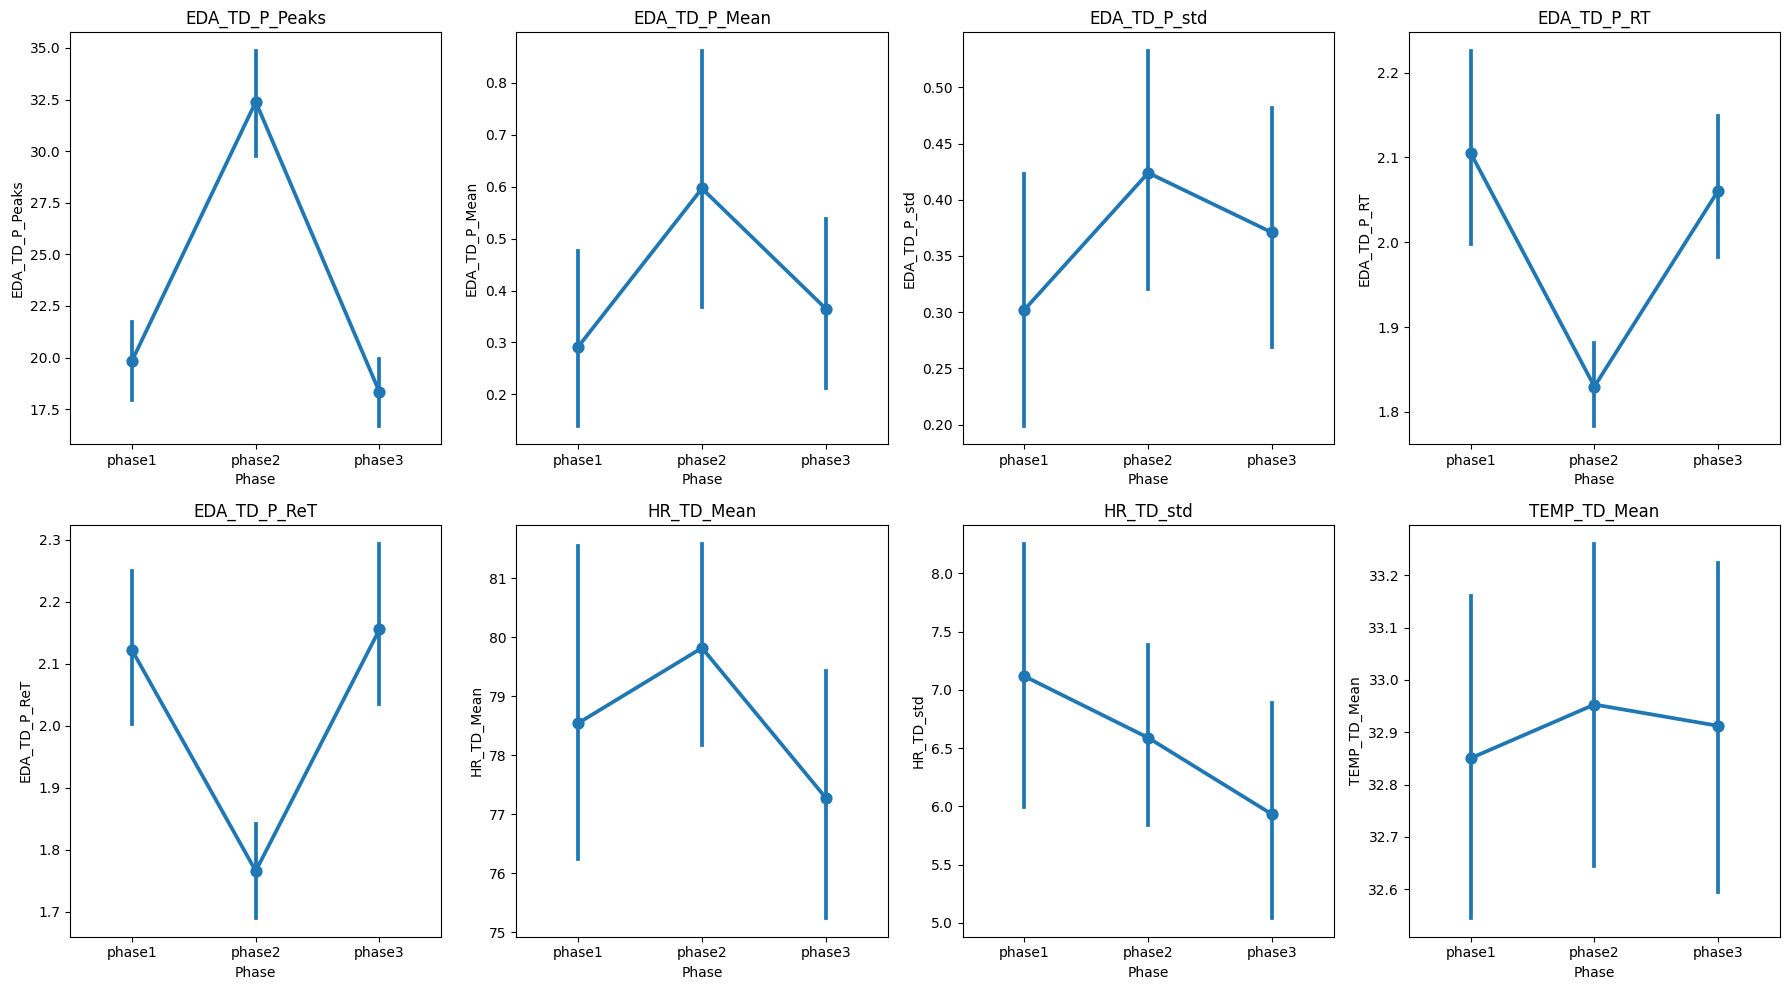

In [14]:


features_to_plot = [
    "EDA_TD_P_Peaks",
    "EDA_TD_P_Mean",
    "EDA_TD_P_std",
    "EDA_TD_P_RT",
    "EDA_TD_P_ReT",
    "HR_TD_Mean",
    "HR_TD_std",
    "TEMP_TD_Mean"
]

fig, axes = plt.subplots(2, 4, figsize=(18, 10))

for ax, feat in zip(axes.flatten(), features_to_plot):
    sns.pointplot(data=df, x="Phase", y=feat, order=["phase1", "phase2", "phase3"], ax=ax)
    ax.set_title(feat)

plt.tight_layout()
plt.show()

=== recovery patterns ===
recovery_type
carry_over          17
overcompensation    11
no_response         11
full_recovery        8
Name: count, dtype: int64

--- full_recovery ---
Phase              phase1  phase2  phase3  diff_21  diff_31
EDA_TD_P_Peaks     19.846  32.385  18.327   12.538   -1.519
EDA_TD_P_Kurtosis  14.925   8.368  14.706   -6.557   -0.219
EDA_TD_P_Skew       3.306   2.397   3.235   -0.908   -0.070
EDA_TD_P_ReT        2.122   1.766   2.155   -0.356    0.033
EDA_TD_P_Mean       0.292   0.597   0.365    0.305    0.073

--- carry_over ---
Phase           phase1  phase2  phase3  diff_21  diff_31
HR_TD_Min       67.694  69.629  69.012    1.935    1.318
HR_TD_Max       94.099  92.868  90.386   -1.230   -3.712
EDA_TD_P_Max     1.608   2.296   2.029    0.688    0.421
HR_TD_Kurtosis   0.258  -0.415  -0.007   -0.673   -0.265
HR_TD_std        7.116   6.588   5.932   -0.528   -1.184

--- overcompensation ---
Phase            phase1  phase2  phase3  diff_21  diff_31
HR_TD_Mean   

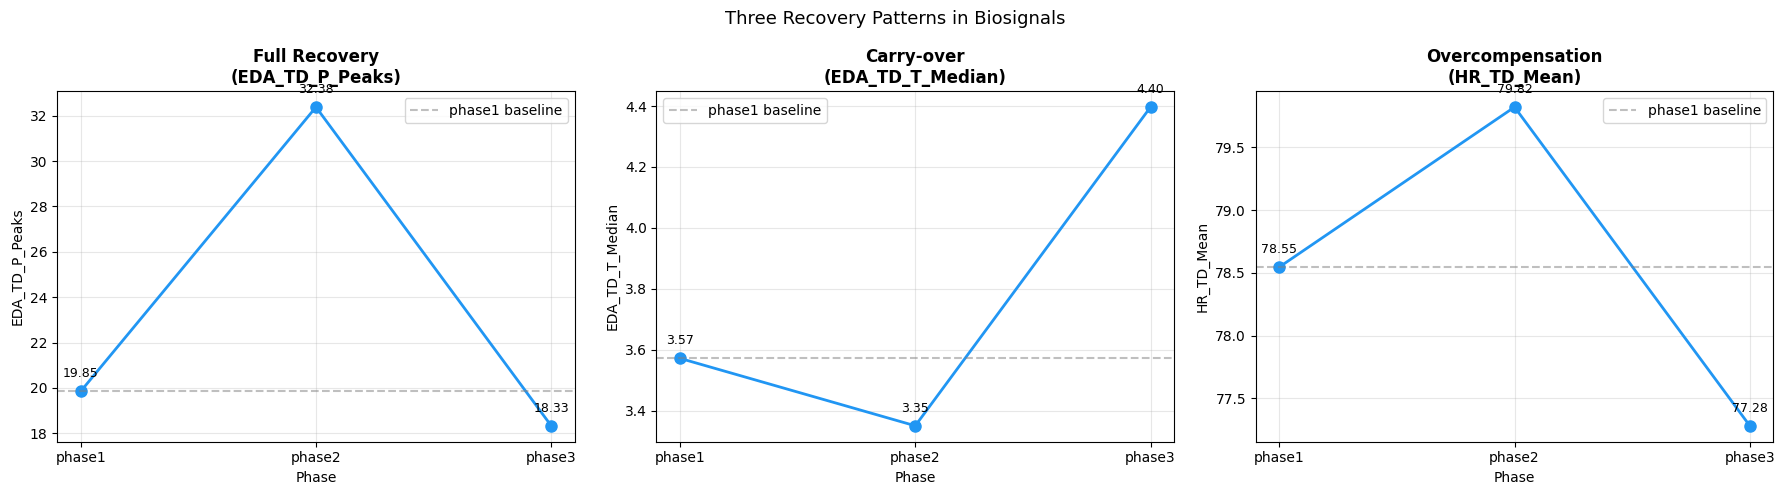

In [15]:

non_auc = [c for c in feature_cols if 'AUC' not in c]

phase_means_clean = df.groupby(
    "Phase", observed=True
)[non_auc].mean().T

phase_means_clean['diff_21'] = (
    phase_means_clean['phase2'] - phase_means_clean['phase1']
)
phase_means_clean['diff_31'] = (
    phase_means_clean['phase3'] - phase_means_clean['phase1']
)
phase_means_clean['abs_diff'] = phase_means_clean['diff_21'].abs()
phase_means_clean['pct_shift'] = (
    phase_means_clean['diff_21'] /
    phase_means_clean['phase1'].abs() * 100
).round(1)

phase_means_clean['recovery_type'] = 'unknown'

for idx in phase_means_clean.index:
    d21 = phase_means_clean.loc[idx, 'diff_21']
    d31 = phase_means_clean.loc[idx, 'diff_31']

    if abs(d21) < 0.01:
        phase_means_clean.loc[idx, 'recovery_type'] = 'no_response'
    elif abs(d31) <= abs(d21) * 0.3:
        phase_means_clean.loc[idx, 'recovery_type'] = 'full_recovery'
    elif (d21 > 0 and d31 > 0) or (d21 < 0 and d31 < 0):
        phase_means_clean.loc[idx, 'recovery_type'] = 'carry_over'
    else:
        phase_means_clean.loc[idx, 'recovery_type'] = 'overcompensation'

print("=== recovery patterns ===")
print(phase_means_clean['recovery_type'].value_counts())

for rtype in ['full_recovery', 'carry_over', 'overcompensation', 'no_response']:
    subset = phase_means_clean[
        phase_means_clean['recovery_type'] == rtype
    ].sort_values('abs_diff', ascending=False).head(5)
    print(f"\n--- {rtype} ---")
    print(subset[['phase1', 'phase2', 'phase3',
                  'diff_21', 'diff_31']].round(3))


# ================================
slope_cols = [c for c in feature_cols if 'Slope' in c]
slope_means = df.groupby(
    'Phase', observed=True
)[slope_cols].mean().T

slope_means['diff_21'] = (
    slope_means['phase2'] - slope_means['phase1']
)
slope_means['diff_31'] = (
    slope_means['phase3'] - slope_means['phase1']
)
slope_means['abs_diff'] = slope_means['diff_21'].abs()

print("\n=== SLOPE by phases ===")
print(
    slope_means
    .sort_values('abs_diff', ascending=False)
    [['phase1', 'phase2', 'phase3', 'diff_21', 'diff_31']]
    .round(4)
)

#plot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
phase_order = ['phase1', 'phase2', 'phase3']

examples = {
    'Full Recovery\n(EDA_TD_P_Peaks)': 'EDA_TD_P_Peaks',
    'Carry-over\n(EDA_TD_T_Median)': 'EDA_TD_T_Median',
    'Overcompensation\n(HR_TD_Mean)': 'HR_TD_Mean'
}

for ax, (title, feat) in zip(axes, examples.items()):
    means = df.groupby(
        'Phase', observed=True
    )[feat].mean()[phase_order]

    ax.plot(phase_order, means.values,
            'o-', linewidth=2, markersize=8, color='#2196F3')
    ax.axhline(y=means['phase1'],
               color='grey', linestyle='--',
               alpha=0.5, label='phase1 baseline')

    for i, (phase, val) in enumerate(zip(phase_order, means.values)):
        ax.annotate(f'{val:.2f}',
                   xy=(i, val),
                   xytext=(0, 10),
                   textcoords='offset points',
                   ha='center', fontsize=9)

    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Phase')
    ax.set_ylabel(feat)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Three Recovery Patterns in Biosignals', fontsize=13)
plt.tight_layout()
plt.show()

Full recovery:    6 features
Carry-over:       4 features
Overcompensation: 4 features
Informative total:14 features
No response:      37 features


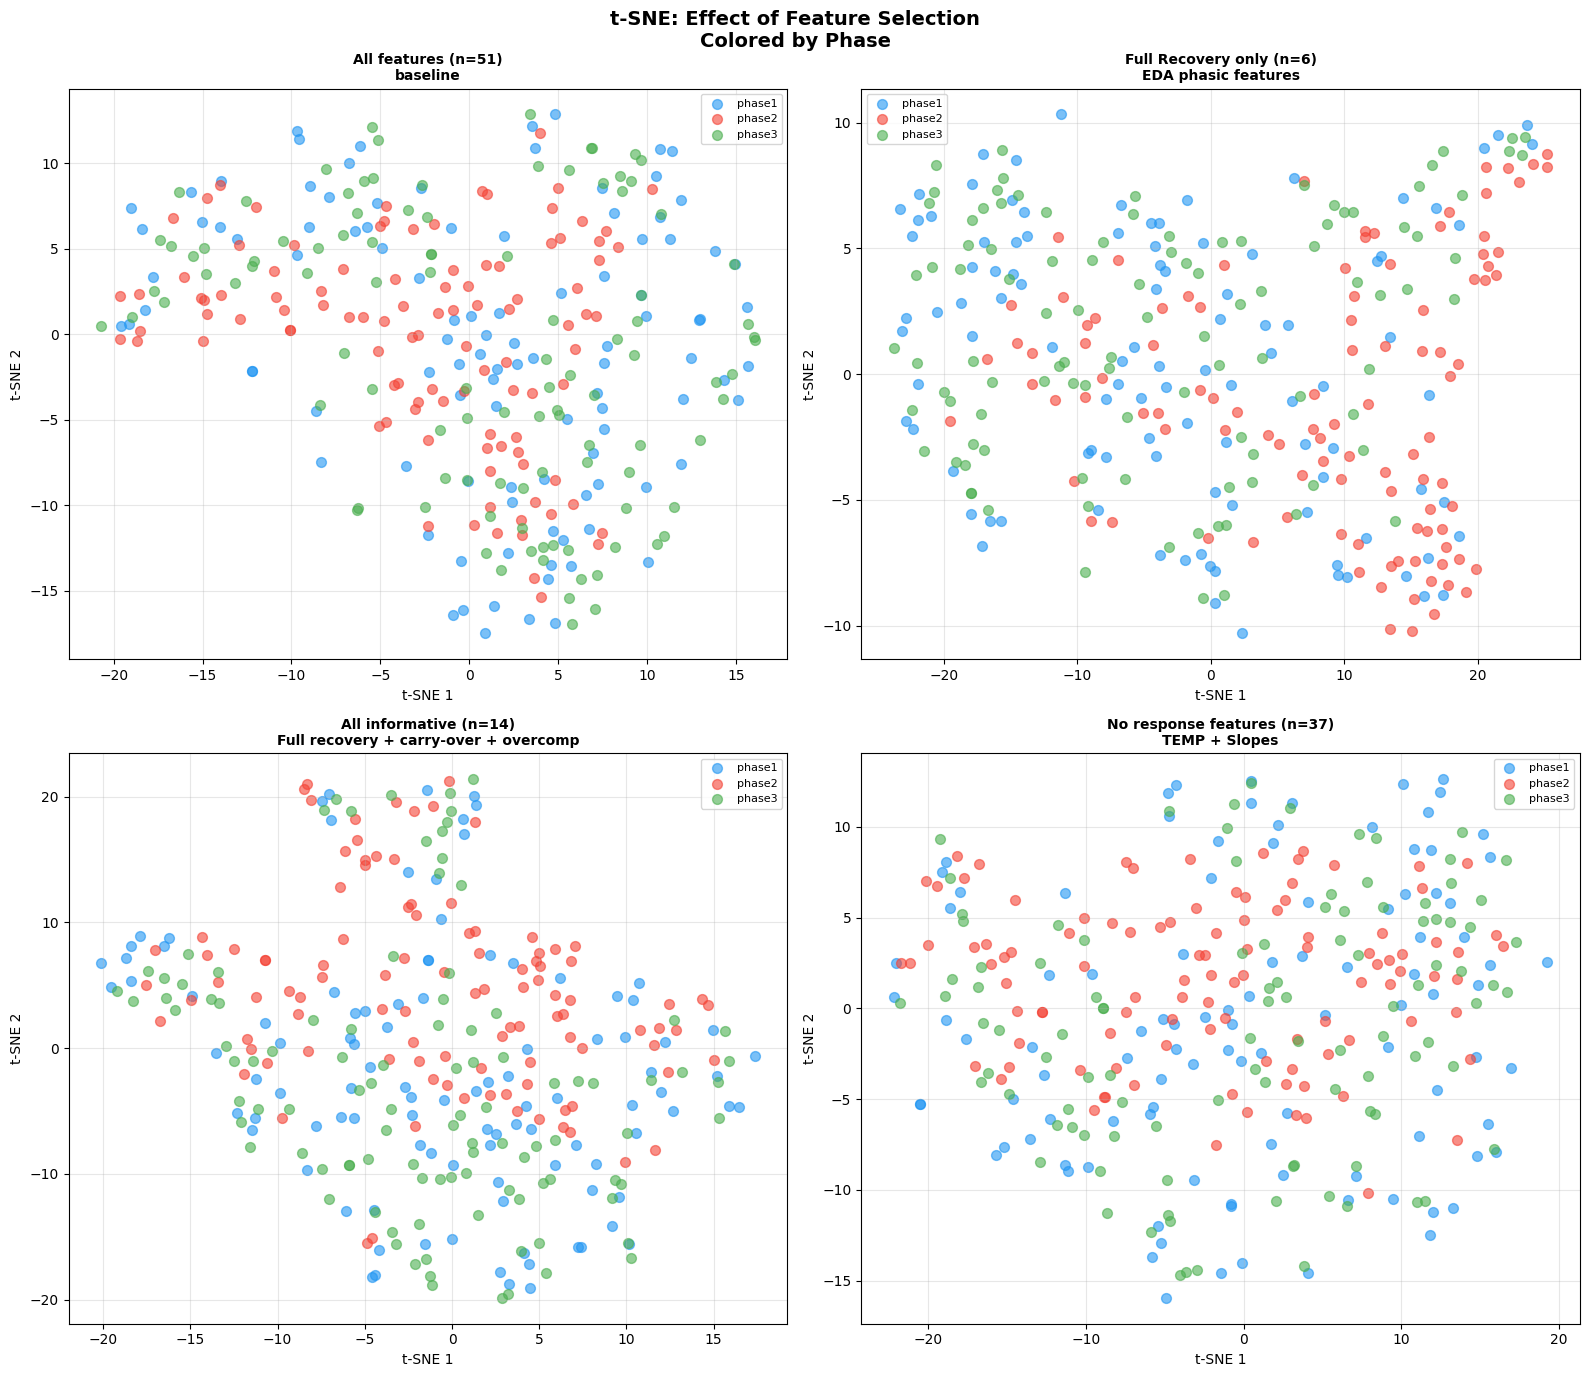

In [16]:
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

phase_order = ['phase1', 'phase2', 'phase3']
palette = {'phase1': '#2196F3',
           'phase2': '#F44336',
           'phase3': '#4CAF50'}



full_recovery_cols = [
    'EDA_TD_P_Peaks', 'EDA_TD_P_Mean', 'EDA_TD_P_std',
    'EDA_TD_P_RT', 'EDA_TD_P_ReT', 'EDA_TD_P_Median'
]

carry_over_cols = [
    'EDA_TD_T_Mean', 'EDA_TD_T_Median',
    'EDA_TD_T_Min', 'EDA_TD_T_Max'
]

overcomp_cols = [
    'HR_TD_Mean', 'HR_TD_Median',
    'HR_TD_Min', 'HR_TD_std'
]

informative_cols = full_recovery_cols + carry_over_cols + overcomp_cols
no_response_cols = [c for c in feature_cols
                    if c not in informative_cols]

print(f"Full recovery:    {len(full_recovery_cols)} features")
print(f"Carry-over:       {len(carry_over_cols)} features")
print(f"Overcompensation: {len(overcomp_cols)} features")
print(f"Informative total:{len(informative_cols)} features")
print(f"No response:      {len(no_response_cols)} features")


def run_tsne_and_plot(ax, X, title, perplexity=30):

    X_clean = X.copy()
    X_clean = X_clean.fillna(X_clean.median())

    scaler = StandardScaler()
    X_sc = scaler.fit_transform(X_clean)

    tsne = TSNE(n_components=2,
                perplexity=perplexity,
                random_state=42,
                max_iter=1000)
    X_2d = tsne.fit_transform(X_sc)

    for phase, color in palette.items():
        mask = df['Phase'] == phase
        ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
                  c=color, label=phase,
                  alpha=0.6, s=50)

    ax.set_title(title, fontweight='bold', fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_xlabel('t-SNE 1')
    ax.set_ylabel('t-SNE 2')
    return X_2d


fig, axes = plt.subplots(2, 2, figsize=(16, 14))

tsne_all = run_tsne_and_plot(
    axes[0,0],
    df[feature_cols],
    f'All features (n={len(feature_cols)})\nbaseline'
)

tsne_fr = run_tsne_and_plot(
    axes[0,1],
    df[full_recovery_cols],
    f'Full Recovery only (n={len(full_recovery_cols)})\nEDA phasic features'
)

tsne_inf = run_tsne_and_plot(
    axes[1,0],
    df[informative_cols],
    f'All informative (n={len(informative_cols)})\nFull recovery + carry-over + overcomp'
)

tsne_nr = run_tsne_and_plot(
    axes[1,1],
    df[no_response_cols],
    f'No response features (n={len(no_response_cols)})\nTEMP + Slopes'
)

plt.suptitle('t-SNE: Effect of Feature Selection\nColored by Phase',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

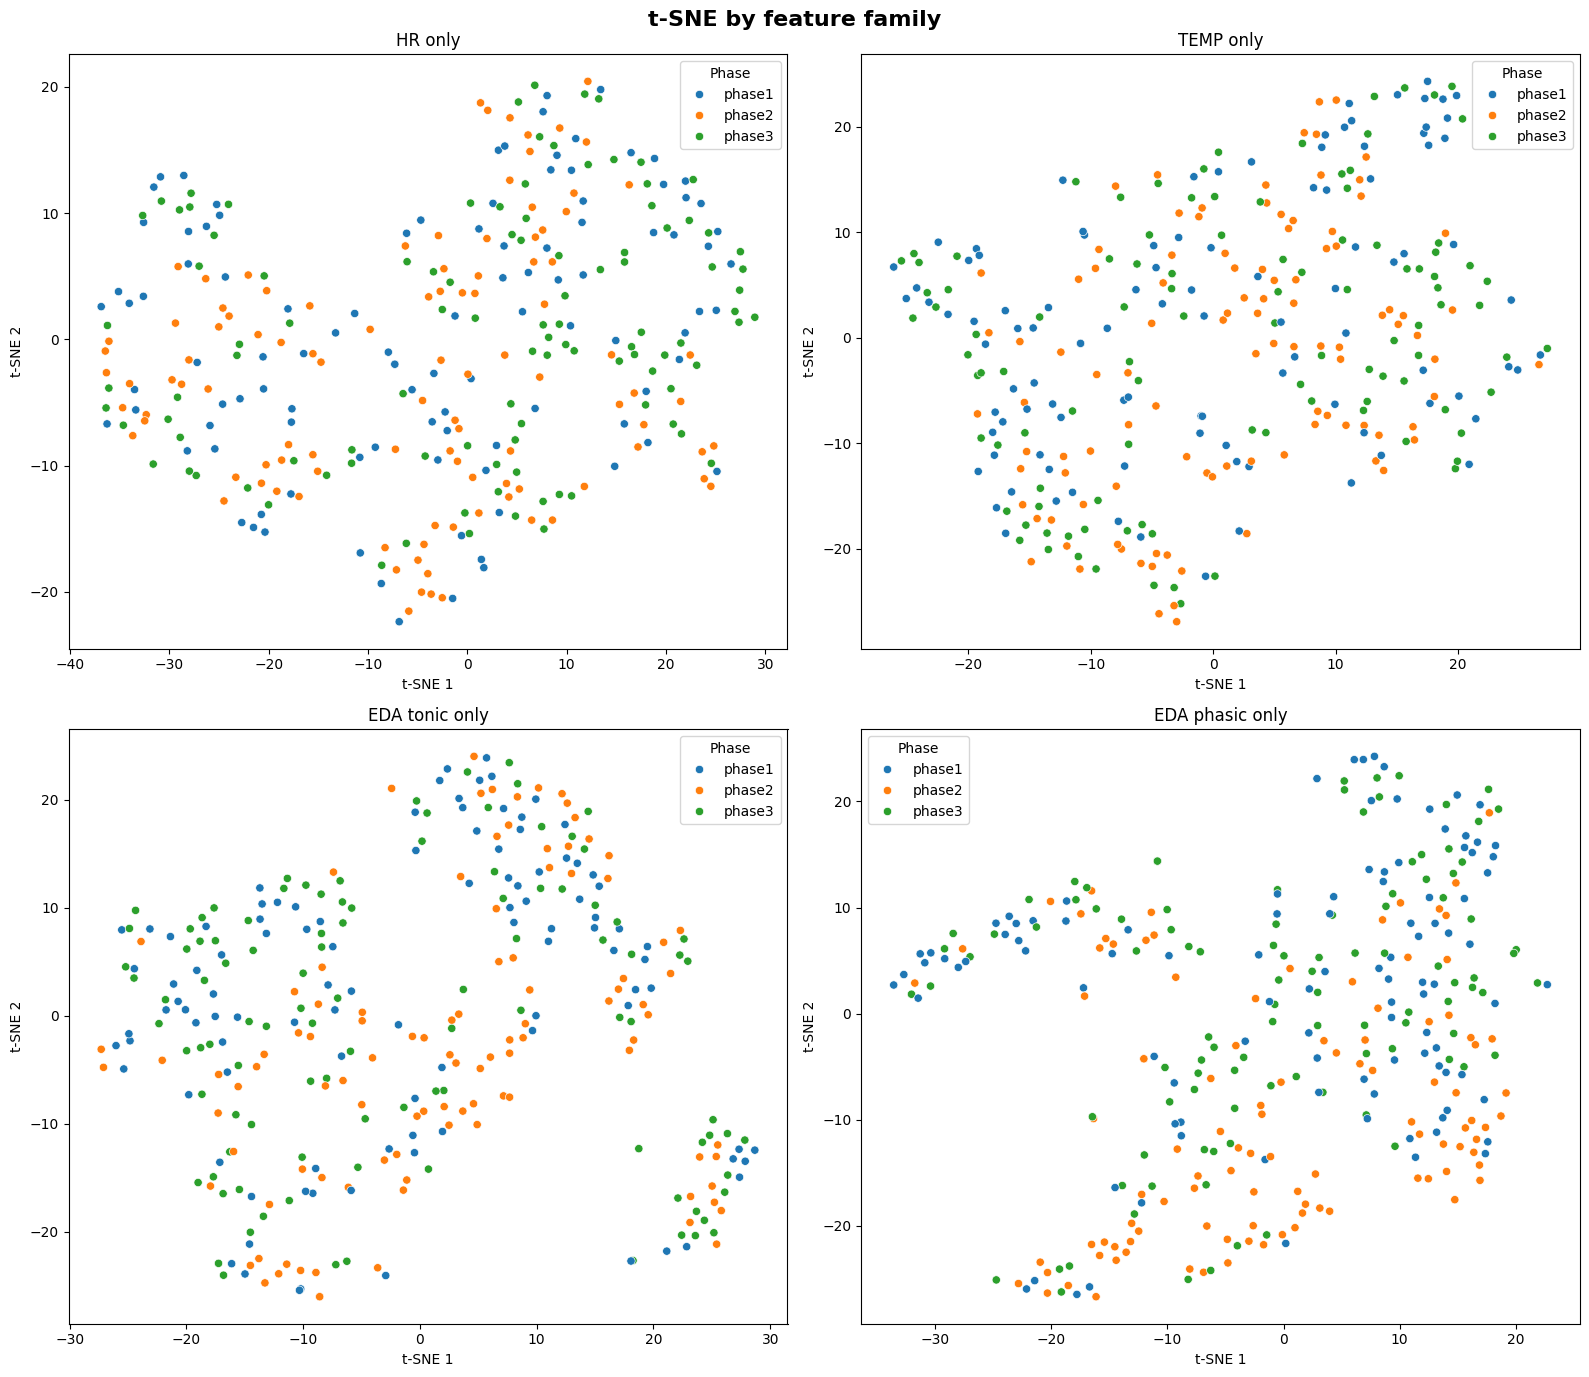

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import RobustScaler
from sklearn.manifold import TSNE


hr_cols = [c for c in df.columns if c.startswith("HR_")]
temp_cols = [c for c in df.columns if c.startswith("TEMP_")]
eda_p_cols = [c for c in df.columns if c.startswith("EDA_TD_P_")]
eda_t_cols = [c for c in df.columns if c.startswith("EDA_TD_T_")]

feature_families = {
    "HR only": hr_cols,
    "TEMP only": temp_cols,
    "EDA tonic only": eda_t_cols,
    "EDA phasic only": eda_p_cols,
}


def run_tsne_family(ax, data, title, hue_values, perplexity=20, random_state=42):
    X = data.copy()
    X = X.replace([np.inf, -np.inf], np.nan)
    X = X.fillna(X.median(numeric_only=True))

    # remove constant columns if any
    constant_cols = [c for c in X.columns if X[c].nunique() <= 1]
    X = X.drop(columns=constant_cols)

    scaler = RobustScaler()
    X_scaled = scaler.fit_transform(X)

    tsne = TSNE(
        n_components=2,
        perplexity=perplexity,
        learning_rate="auto",
        init="random",
        random_state=random_state
    )
    X_tsne = tsne.fit_transform(X_scaled)

    plot_df = pd.DataFrame({
        "tsne1": X_tsne[:, 0],
        "tsne2": X_tsne[:, 1],
        "Phase": hue_values.values
    })

    sns.scatterplot(data=plot_df, x="tsne1", y="tsne2", hue="Phase", ax=ax)
    ax.set_title(title)
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")


fig, axes = plt.subplots(2, 2, figsize=(16, 14))

for ax, (name, cols) in zip(axes.flatten(), feature_families.items()):
    run_tsne_family(
        ax=ax,
        data=df[cols],
        title=name,
        hue_values=df["Phase"],
        perplexity=20
    )

plt.suptitle("t-SNE by feature family", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

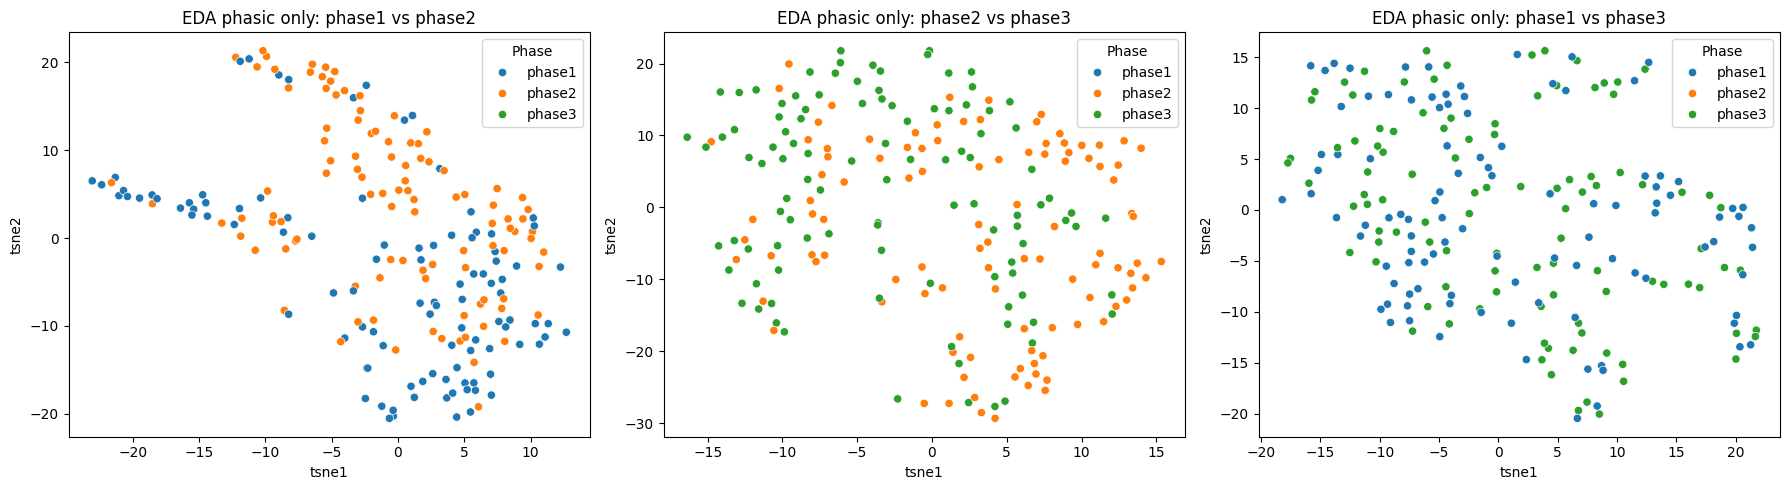

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import RobustScaler
from sklearn.manifold import TSNE

eda_p_cols = [c for c in df.columns if c.startswith("EDA_TD_P_")]

phase_pairs = [
    ["phase1", "phase2"],
    ["phase2", "phase3"],
    ["phase1", "phase3"]
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, pair in zip(axes, phase_pairs):
    df_pair = df[df["Phase"].isin(pair)].copy()

    X = df_pair[eda_p_cols].copy()
    X = X.replace([np.inf, -np.inf], np.nan)
    X = X.fillna(X.median(numeric_only=True))

    constant_cols = [c for c in X.columns if X[c].nunique() <= 1]
    X = X.drop(columns=constant_cols)

    scaler = RobustScaler()
    X_scaled = scaler.fit_transform(X)

    X_tsne = TSNE(
        n_components=2,
        perplexity=20,
        learning_rate="auto",
        init="random",
        random_state=42
    ).fit_transform(X_scaled)

    plot_df = pd.DataFrame({
        "tsne1": X_tsne[:, 0],
        "tsne2": X_tsne[:, 1],
        "Phase": df_pair["Phase"].values
    })

    sns.scatterplot(data=plot_df, x="tsne1", y="tsne2", hue="Phase", ax=ax)
    ax.set_title(f"EDA phasic only: {pair[0]} vs {pair[1]}")

plt.tight_layout()
plt.show()

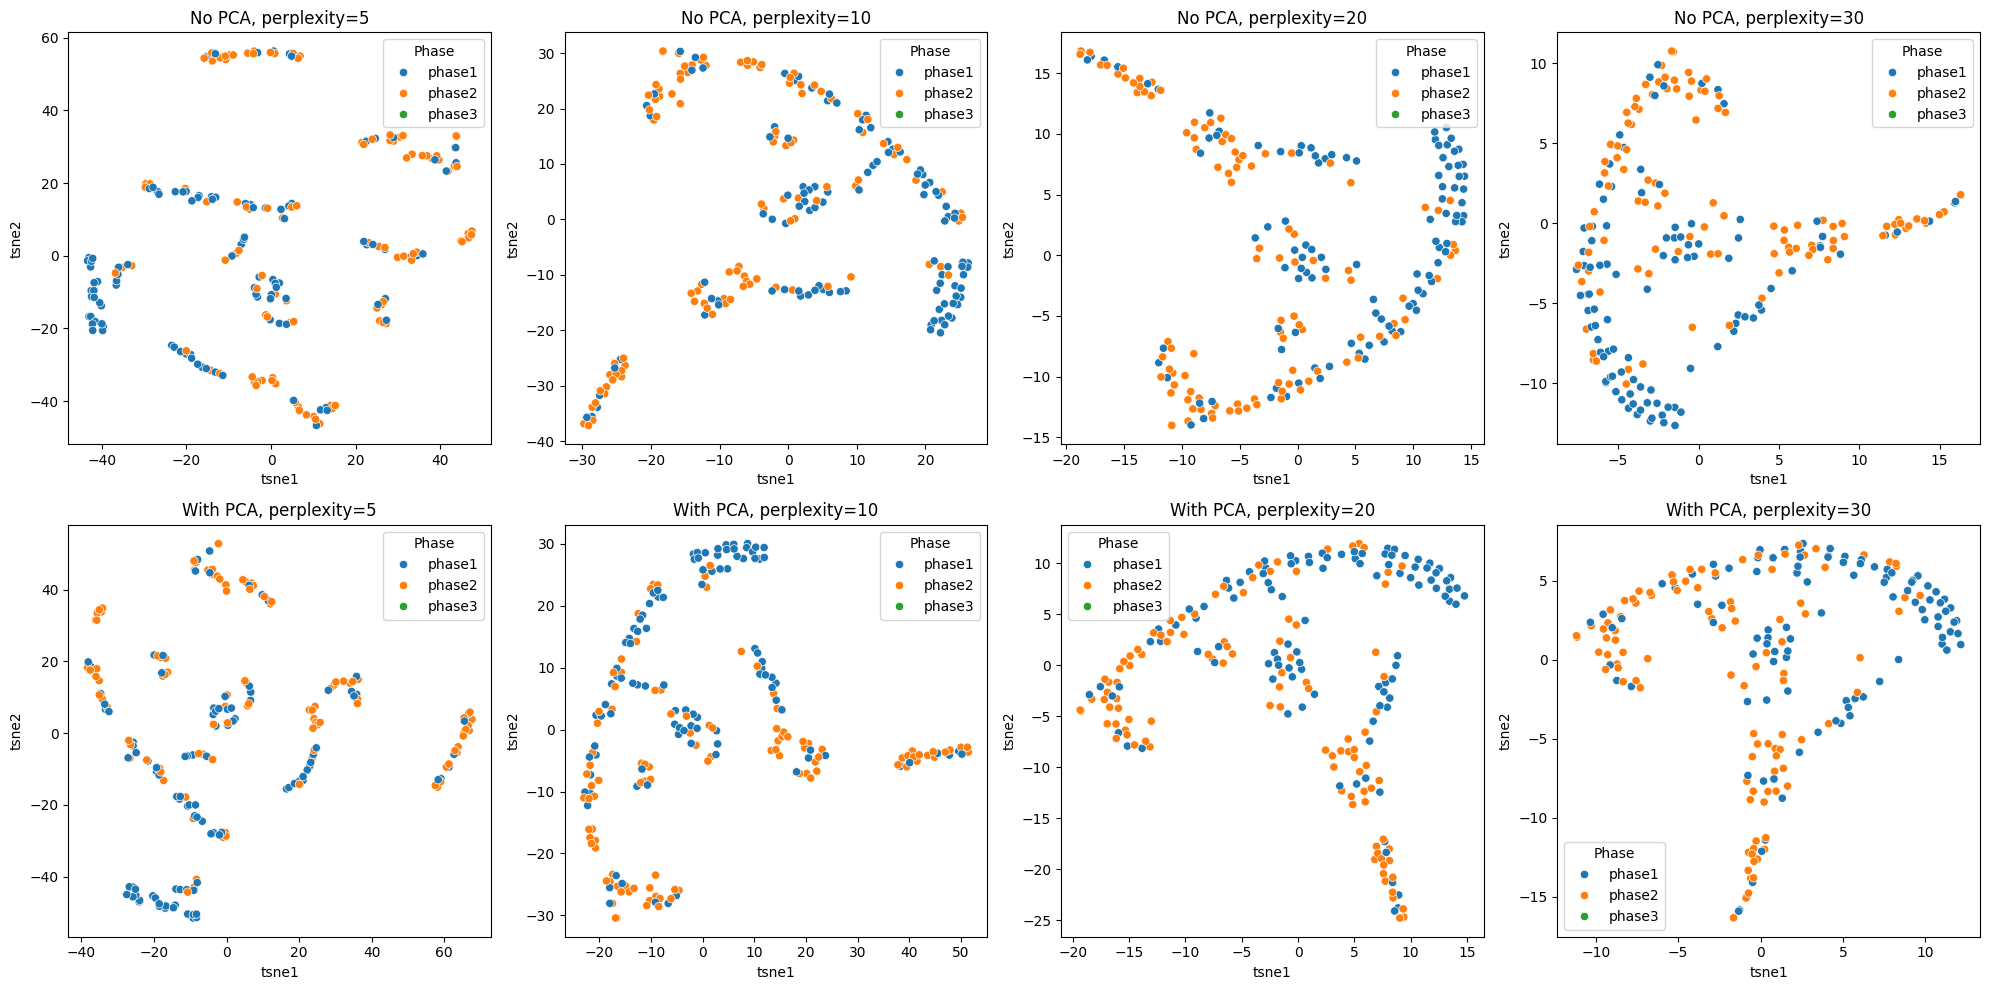

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

best_eda_cols = [

    "EDA_TD_P_Peaks",
    "EDA_TD_P_Mean"
]

df_12 = df[df["Phase"].isin(["phase1", "phase2"])].copy()

X = df_12[best_eda_cols].copy()
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.median(numeric_only=True))

scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

perplexities = [5, 10, 20, 30]

fig, axes = plt.subplots(2, 4, figsize=(20, 10))

for i, perp in enumerate(perplexities):
    # no PCA
    X_tsne = TSNE(
        n_components=2,
        perplexity=perp,
        learning_rate="auto",
        init="random",
        random_state=42
    ).fit_transform(X_scaled)

    plot_df = pd.DataFrame({
        "tsne1": X_tsne[:, 0],
        "tsne2": X_tsne[:, 1],
        "Phase": df_12["Phase"].values
    })

    sns.scatterplot(data=plot_df, x="tsne1", y="tsne2", hue="Phase", ax=axes[0, i])
    axes[0, i].set_title(f"No PCA, perplexity={perp}")

    # with PCA
    n_pca = min(3, X.shape[1], X.shape[0] - 1)
    X_pca = PCA(n_components=n_pca, random_state=42).fit_transform(X_scaled)

    X_tsne_pca = TSNE(
        n_components=2,
        perplexity=perp,
        learning_rate="auto",
        init="pca",
        random_state=42
    ).fit_transform(X_pca)

    plot_df_pca = pd.DataFrame({
        "tsne1": X_tsne_pca[:, 0],
        "tsne2": X_tsne_pca[:, 1],
        "Phase": df_12["Phase"].values
    })

    sns.scatterplot(data=plot_df_pca, x="tsne1", y="tsne2", hue="Phase", ax=axes[1, i])
    axes[1, i].set_title(f"With PCA, perplexity={perp}")

plt.tight_layout()
plt.show()

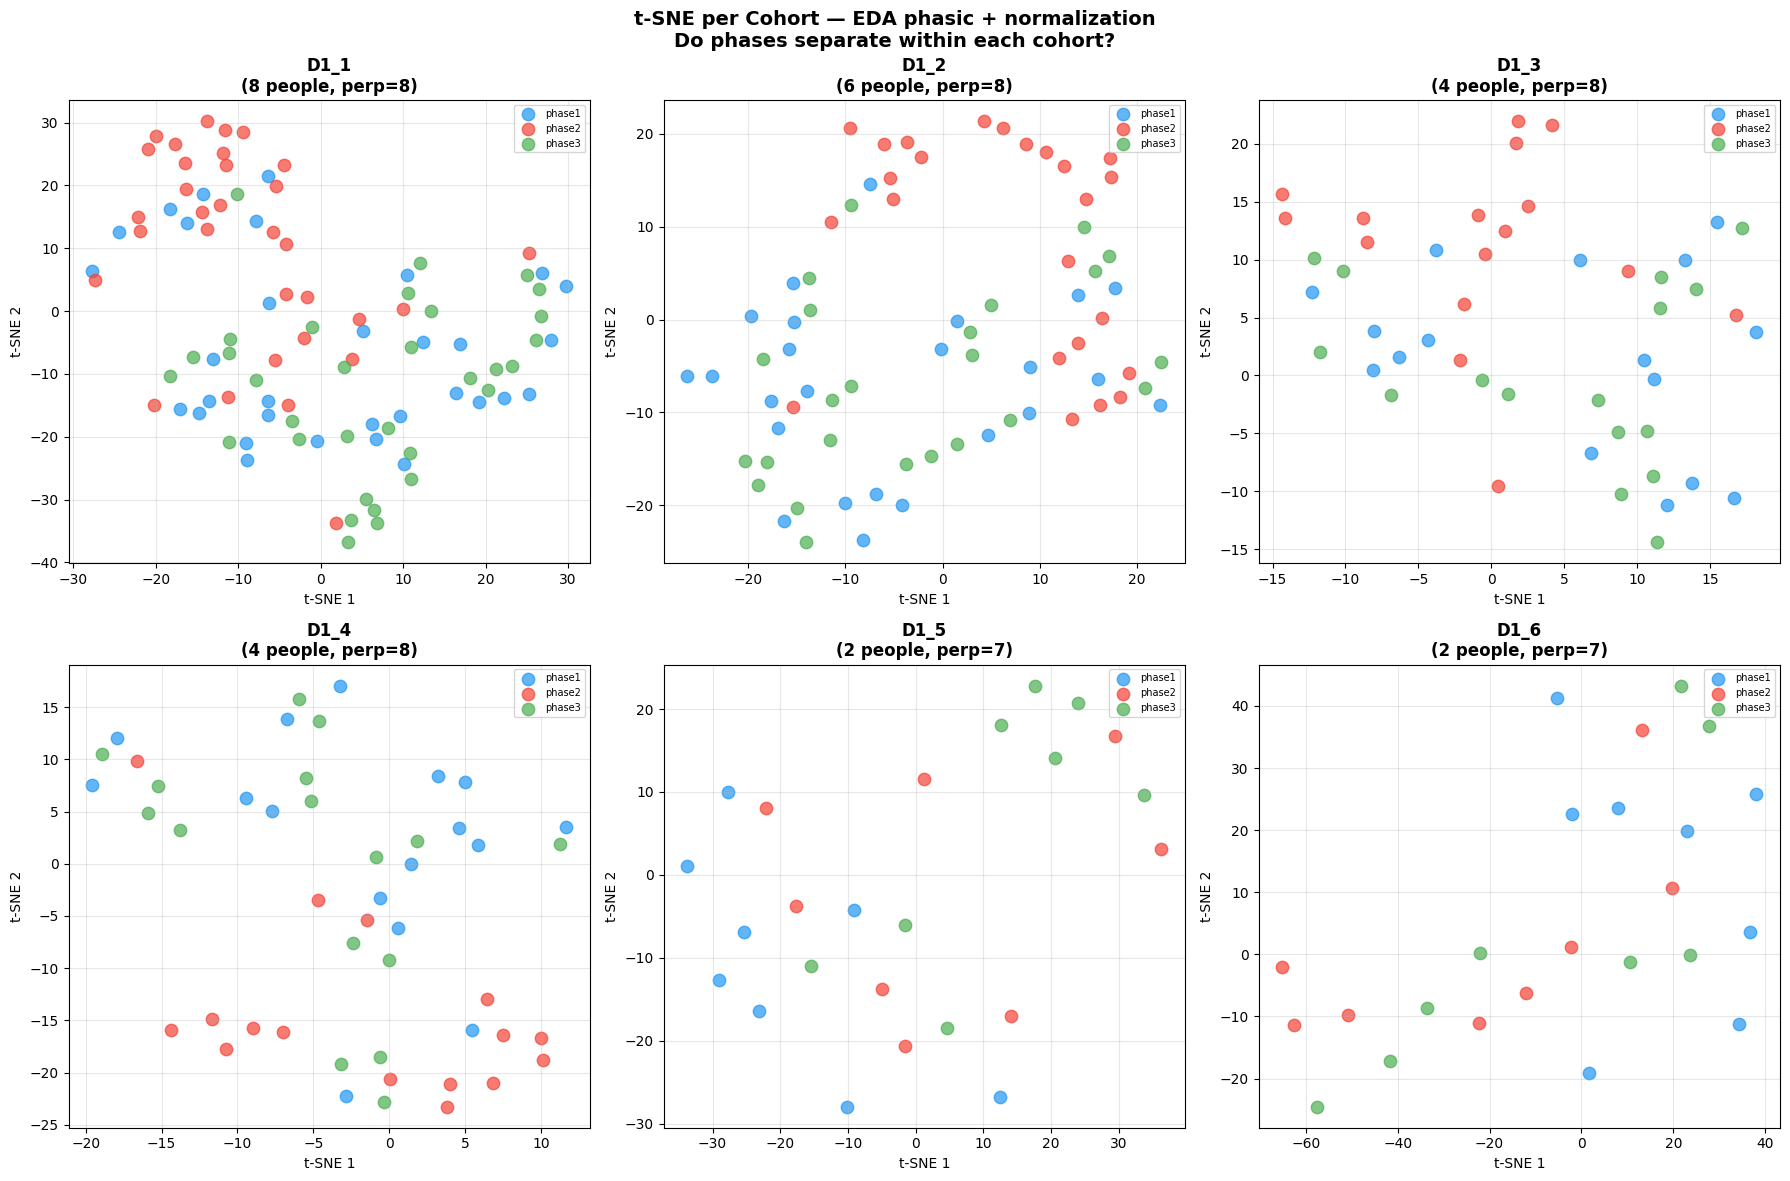

In [21]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

palette = {'phase1': '#2196F3',
           'phase2': '#F44336',
           'phase3': '#4CAF50'}

eda_p_cols = [
    'EDA_TD_P_Peaks', 'EDA_TD_P_Mean',
    'EDA_TD_P_std', 'EDA_TD_P_RT',
    'EDA_TD_P_ReT'
]

cohorts = sorted(df['Cohort'].unique().tolist())

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

for ax, cohort in zip(axes.flatten(), cohorts):

    mask = df['Cohort'] == cohort
    df_cohort = df[mask].copy()
    n_people = df_cohort['Individual'].nunique()
    n_points = mask.sum()


    X_cohort = df_cohort[eda_p_cols].fillna(
        df_cohort[eda_p_cols].median()
    ).astype(float)

    X_norm = X_cohort.copy()
    for ind in df_cohort['Individual'].unique():
        ind_mask = df_cohort['Individual'] == ind
        X_norm.loc[ind_mask] = (
            X_cohort.loc[ind_mask] -
            X_cohort.loc[ind_mask].mean()
        )

    X_sc = StandardScaler().fit_transform(X_norm)


    perp = max(2, min(8, n_points // 3 - 1))

    tsne = TSNE(n_components=2,
                perplexity=perp,
                random_state=42,
                max_iter=1000)
    X_2d = tsne.fit_transform(X_sc)

    for phase, color in palette.items():
        phase_mask = df_cohort['Phase'].values == phase
        ax.scatter(
            X_2d[phase_mask, 0],
            X_2d[phase_mask, 1],
            c=color, label=phase,
            alpha=0.7, s=80
        )

    ax.set_title(f'{cohort}\n'
                 f'({n_people} people, perp={perp})',
                 fontweight='bold')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)
    ax.set_xlabel('t-SNE 1')
    ax.set_ylabel('t-SNE 2')

plt.suptitle('t-SNE per Cohort — EDA phasic + normalization\n'
             'Do phases separate within each cohort?',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


Groups:
CohortGroup
Evening (D1_4+D1_6)    6
Fall large (D1_2)      6
Morning (D1_3+D1_5)    6
Winter (D1_1)          8
Name: Individual, dtype: int64


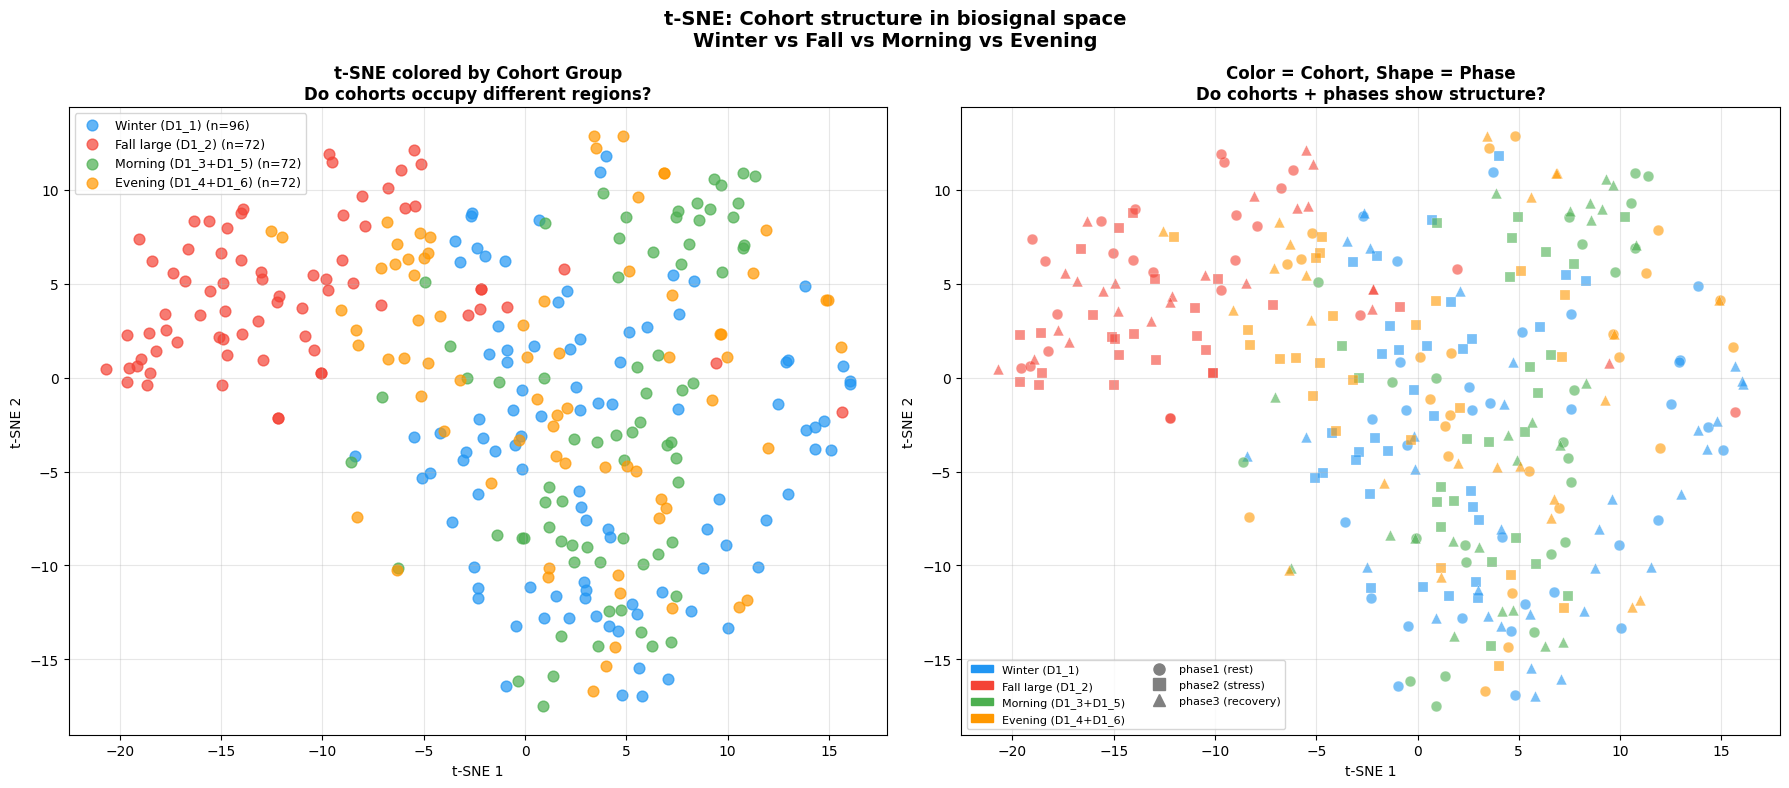

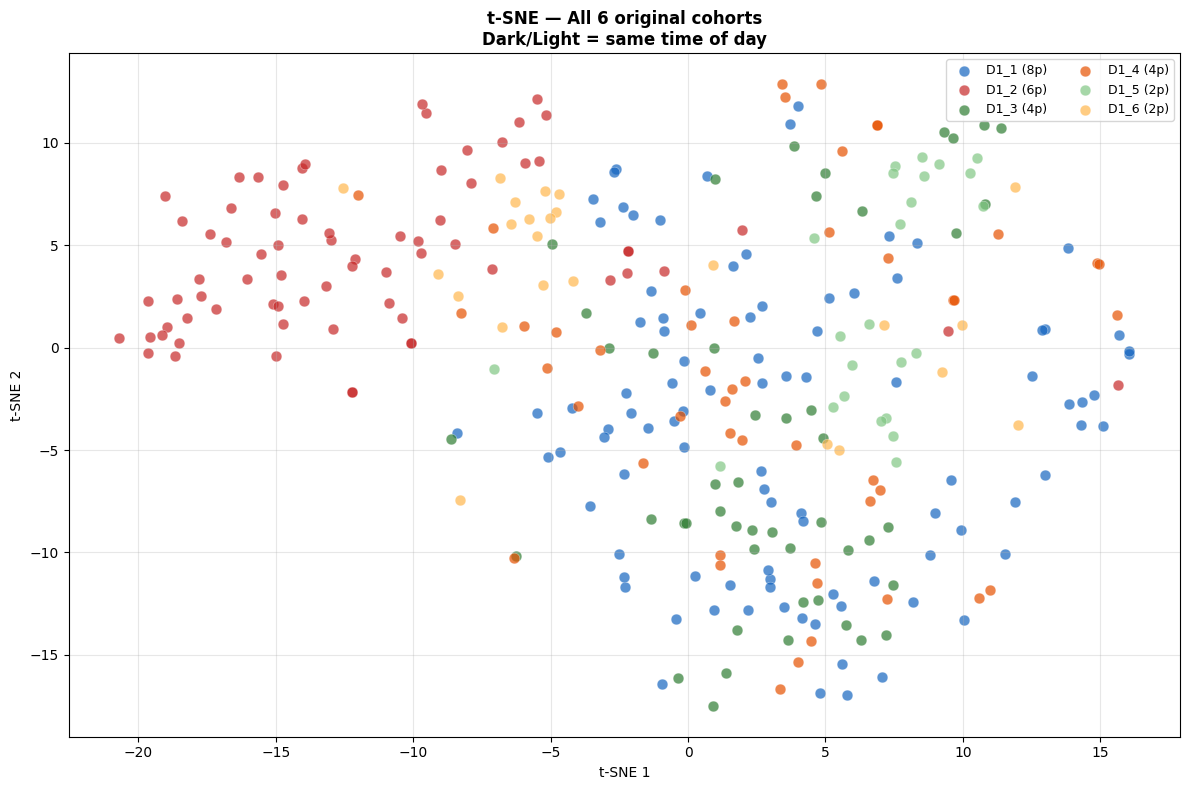

In [23]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import numpy as np


df['CohortGroup'] = df['Cohort'].map({
    'D1_1': 'Winter (D1_1)',
    'D1_2': 'Fall large (D1_2)',
    'D1_3': 'Morning (D1_3+D1_5)',
    'D1_4': 'Evening (D1_4+D1_6)',
    'D1_5': 'Morning (D1_3+D1_5)',
    'D1_6': 'Evening (D1_4+D1_6)'
})

print("Groups:")
print(df.groupby('CohortGroup')['Individual'].nunique())


cohort_palette = {
    'Winter (D1_1)':        '#2196F3',  # blue
    'Fall large (D1_2)':    '#F44336',  # read
    'Morning (D1_3+D1_5)':  '#4CAF50',  # green
    'Evening (D1_4+D1_6)':  '#FF9800',  # orange
}

phase_markers = {
    'phase1': 'o',   # circle
    'phase2': 's',   # square
    'phase3': '^'    # triangle
}


X_clean = df[feature_cols].fillna(
    df[feature_cols].median()
).astype(float)

X_sc = StandardScaler().fit_transform(X_clean)

tsne = TSNE(n_components=2, perplexity=30,
            random_state=42, max_iter=1000)
X_tsne_coh = tsne.fit_transform(X_sc)


fig, axes = plt.subplots(1, 2, figsize=(18, 8))


for group, color in cohort_palette.items():
    mask = df['CohortGroup'] == group
    n = mask.sum()
    axes[0].scatter(
        X_tsne_coh[mask, 0],
        X_tsne_coh[mask, 1],
        c=color,
        label=f'{group} (n={n})',
        alpha=0.7, s=60
    )
axes[0].set_title('t-SNE colored by Cohort Group\n'
                  'Do cohorts occupy different regions?',
                  fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)
axes[0].set_xlabel('t-SNE 1')
axes[0].set_ylabel('t-SNE 2')

for group, color in cohort_palette.items():
    for phase, marker in phase_markers.items():
        mask = (df['CohortGroup'] == group) & \
               (df['Phase'] == phase)
        axes[1].scatter(
            X_tsne_coh[mask, 0],
            X_tsne_coh[mask, 1],
            c=color, marker=marker,
            alpha=0.6, s=60,
            edgecolors='white', linewidth=0.3
        )


from matplotlib.lines import Line2D
from matplotlib.patches import Patch

legend_cohort = [
    Patch(color=c, label=g)
    for g, c in cohort_palette.items()
]
legend_phase = [
    Line2D([0], [0], marker='o', color='grey',
           label='phase1 (rest)', markersize=8,
           linestyle='None'),
    Line2D([0], [0], marker='s', color='grey',
           label='phase2 (stress)', markersize=8,
           linestyle='None'),
    Line2D([0], [0], marker='^', color='grey',
           label='phase3 (recovery)', markersize=8,
           linestyle='None'),
]
axes[1].legend(
    handles=legend_cohort + legend_phase,
    fontsize=8, ncol=2
)
axes[1].set_title('Color = Cohort, Shape = Phase\n'
                  'Do cohorts + phases show structure?',
                  fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].set_xlabel('t-SNE 1')
axes[1].set_ylabel('t-SNE 2')

plt.suptitle('t-SNE: Cohort structure in biosignal space\n'
             'Winter vs Fall vs Morning vs Evening',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


fig, ax = plt.subplots(figsize=(12, 8))

original_palette = {
    'D1_1': '#1565C0',  #
    'D1_2': '#C62828',  #
    'D1_3': '#2E7D32',  #
    'D1_4': '#E65100',  #
    'D1_5': '#81C784',
    'D1_6': '#FFB74D',
}

for cohort, color in original_palette.items():
    mask = df['Cohort'] == cohort
    n_people = df[mask]['Individual'].nunique()
    ax.scatter(
        X_tsne_coh[mask, 0],
        X_tsne_coh[mask, 1],
        c=color,
        label=f'{cohort} ({n_people}p)',
        alpha=0.7, s=60,
        edgecolors='white', linewidth=0.3
    )

ax.set_title('t-SNE — All 6 original cohorts\n'
             'Dark/Light = same time of day',
             fontweight='bold', fontsize=12)
ax.legend(fontsize=9, ncol=2)
ax.grid(True, alpha=0.3)
ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')
plt.tight_layout()
plt.show()


from sklearn.metrics import adjusted_rand_score
from sklearn.cluster import KMeans

km2 = KMeans(n_clusters=2, random_state=42, n_init=10)
cluster_labels = km2.fit_predict(X_sc)

cohort_numeric = pd.factorize(df['Cohort'])[0]
group_numeric = pd.factorize(df['CohortGroup'])[0]

ari_cohort = adjusted_rand_score(cohort_numeric, cluster_labels)
ari_group = adjusted_rand_score(group_numeric, cluster_labels)
ari_phase = adjusted_rand_score(
    pd.factorize(df['Phase'])[0], cluster_labels
)



In [29]:
# ================================
# Пересчитываем на полном датасете
# ================================
X_full = df[feature_cols].fillna(
    df[feature_cols].median()
).astype(float)

X_full_scaled = StandardScaler().fit_transform(X_full)

# Пересчитываем t-SNE на полных данных
X_tsne = TSNE(n_components=2, perplexity=30,
              random_state=42, max_iter=1000
              ).fit_transform(X_full_scaled)

# Теперь K-Means на полных данных
km = KMeans(n_clusters=2, random_state=42, n_init=10)
cluster_labels = km.fit_predict(X_full_scaled)

df_temp = df.copy()  # 312 строк ✅
df_temp['cluster'] = cluster_labels  # 312 = 312 ✅

In [30]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np


km = KMeans(n_clusters=2, random_state=42, n_init=10)
cluster_labels = km.fit_predict(X_scaled)


df_temp = df.copy()
df_temp['cluster'] = cluster_labels


print("=== Average biosignals by clusters ===")
print(df_temp.groupby('cluster')[
    ['EDA_TD_T_Mean', 'EDA_TD_P_Peaks',
     'HR_TD_Mean', 'TEMP_TD_Mean']
].mean().round(2))

print("\n=== Participants by clusters ===")
participant_clusters = df_temp.groupby(
    ['Individual', 'cluster']
).size().unstack(fill_value=0)
print(participant_clusters)

participant_type = participant_clusters.idxmax(axis=1)
print("\n=== Type of every participant ===")
print(participant_type.value_counts())

fig, axes = plt.subplots(1, 3, figsize=(20, 7))

#clusters
cluster_colors = {0: '#FF9800', 1: '#9C27B0'}
cluster_names = {0: 'Low EDA type', 1: 'High EDA type'}

for c, color in cluster_colors.items():
    mask = cluster_labels == c
    n = mask.sum()
    axes[0].scatter(X_tsne[mask, 0], X_tsne[mask, 1],
                   c=color,
                   label=f'{cluster_names[c]} (n={n})',
                   alpha=0.7, s=60)

axes[0].set_title('Physiological Types\n(K-Means K=2)',
                  fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)
axes[0].set_xlabel('t-SNE 1')
axes[0].set_ylabel('t-SNE 2')

#phases
palette = {'phase1': '#2196F3',
           'phase2': '#F44336',
           'phase3': '#4CAF50'}

for phase, color in palette.items():
    mask = df['Phase'] == phase
    axes[1].scatter(X_tsne[mask, 0], X_tsne[mask, 1],
                   c=color, label=phase,
                   alpha=0.6, s=60)
axes[1].set_title('Experimental Phases\n(what we wanted to find)',
                  fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)
axes[1].set_xlabel('t-SNE 1')


markers = {0: 'o', 1: 's'}
for c, marker in markers.items():
    for phase, color in palette.items():
        mask = (cluster_labels == c) & (df['Phase'] == phase)
        axes[2].scatter(X_tsne[mask, 0], X_tsne[mask, 1],
                       c=color, marker=marker,
                       alpha=0.6, s=60,
                       label=f'{cluster_names[c][:3]}+{phase}'
                             if phase == 'phase1' else '')

#labels
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

legend_elements = [
    Line2D([0], [0], marker='o', color='grey',
           label='Low EDA type', markersize=8, linestyle='None'),
    Line2D([0], [0], marker='s', color='grey',
           label='High EDA type', markersize=8, linestyle='None'),
    Patch(color='#2196F3', label='phase1 (rest)'),
    Patch(color='#F44336', label='phase2 (stress)'),
    Patch(color='#4CAF50', label='phase3 (recovery)'),
]
axes[2].legend(handles=legend_elements, fontsize=8)
axes[2].set_title('Type + Phase combined\n(○=Low EDA, □=High EDA)',
                  fontweight='bold')
axes[2].grid(True, alpha=0.3)
axes[2].set_xlabel('t-SNE 1')

plt.suptitle('t-SNE: Algorithm finds physiological types\nnot experimental stress phases',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


fig, axes = plt.subplots(1, 3, figsize=(15, 5))

signals = ['EDA_TD_T_Mean', 'EDA_TD_P_Peaks', 'HR_TD_Mean']
titles = ['EDA Tonic', 'EDA Phasic Peaks', 'Heart Rate']

for ax, signal, title in zip(axes, signals, titles):
    data = [df_temp[df_temp['cluster'] == c][signal]
            for c in [0, 1]]
    bp = ax.boxplot(data, labels=['Low EDA\ntype', 'High EDA\ntype'],
                   patch_artist=True)
    bp['boxes'][0].set_facecolor('#FF9800')
    bp['boxes'][1].set_facecolor('#9C27B0')
    ax.set_title(title, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')


    for i, d in enumerate(data):
        ax.annotate(f'mean={d.mean():.1f}',
                   xy=(i+1, d.mean()),
                   xytext=(10, 0),
                   textcoords='offset points',
                   fontsize=9, color='black')

plt.suptitle('Biosignal differences between physiological types',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


ValueError: Length of values (208) does not match length of index (312)

In [34]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

X_full = df[feature_cols].fillna(
    df[feature_cols].median()
).astype(float)

X_full_scaled = StandardScaler().fit_transform(X_full)

print("X_full_scaled:", X_full_scaled.shape)
print("df:", df.shape)


from sklearn.manifold import TSNE
X_tsne = TSNE(n_components=2, perplexity=30,
              random_state=42, max_iter=1000
              ).fit_transform(X_full_scaled)

print("X_tsne:", X_tsne.shape)


km = KMeans(n_clusters=2, random_state=42, n_init=10)
cluster_labels = km.fit_predict(X_full_scaled)

print("cluster_labels:", cluster_labels.shape)


df_temp = df.copy()
df_temp['cluster'] = cluster_labels


X_full_scaled: (312, 51)
df: (312, 73)
X_tsne: (312, 2)
cluster_labels: (312,)


=== Average biosignals by clusters ===
         EDA_TD_T_Mean  EDA_TD_P_Peaks  HR_TD_Mean  TEMP_TD_Mean
cluster                                                         
0                 2.41           21.68       78.61         32.64
1                13.00           36.00       78.17         34.74

=== Participants by clusters ===
cluster      0   1
Individual        
1           12   0
10          12   0
11          12   0
12          12   0
13          12   0
14          12   0
15           4   8
16          10   2
17           9   3
18           6   6
19           0  12
2           12   0
20           5   7
21          12   0
22          12   0
23          12   0
24          12   0
25          12   0
26          12   0
3           12   0
4           11   1
5           11   1
6           12   0
7           12   0
8           12   0
9           12   0

=== Type of every participant ===
0    23
1     3
Name: count, dtype: int64


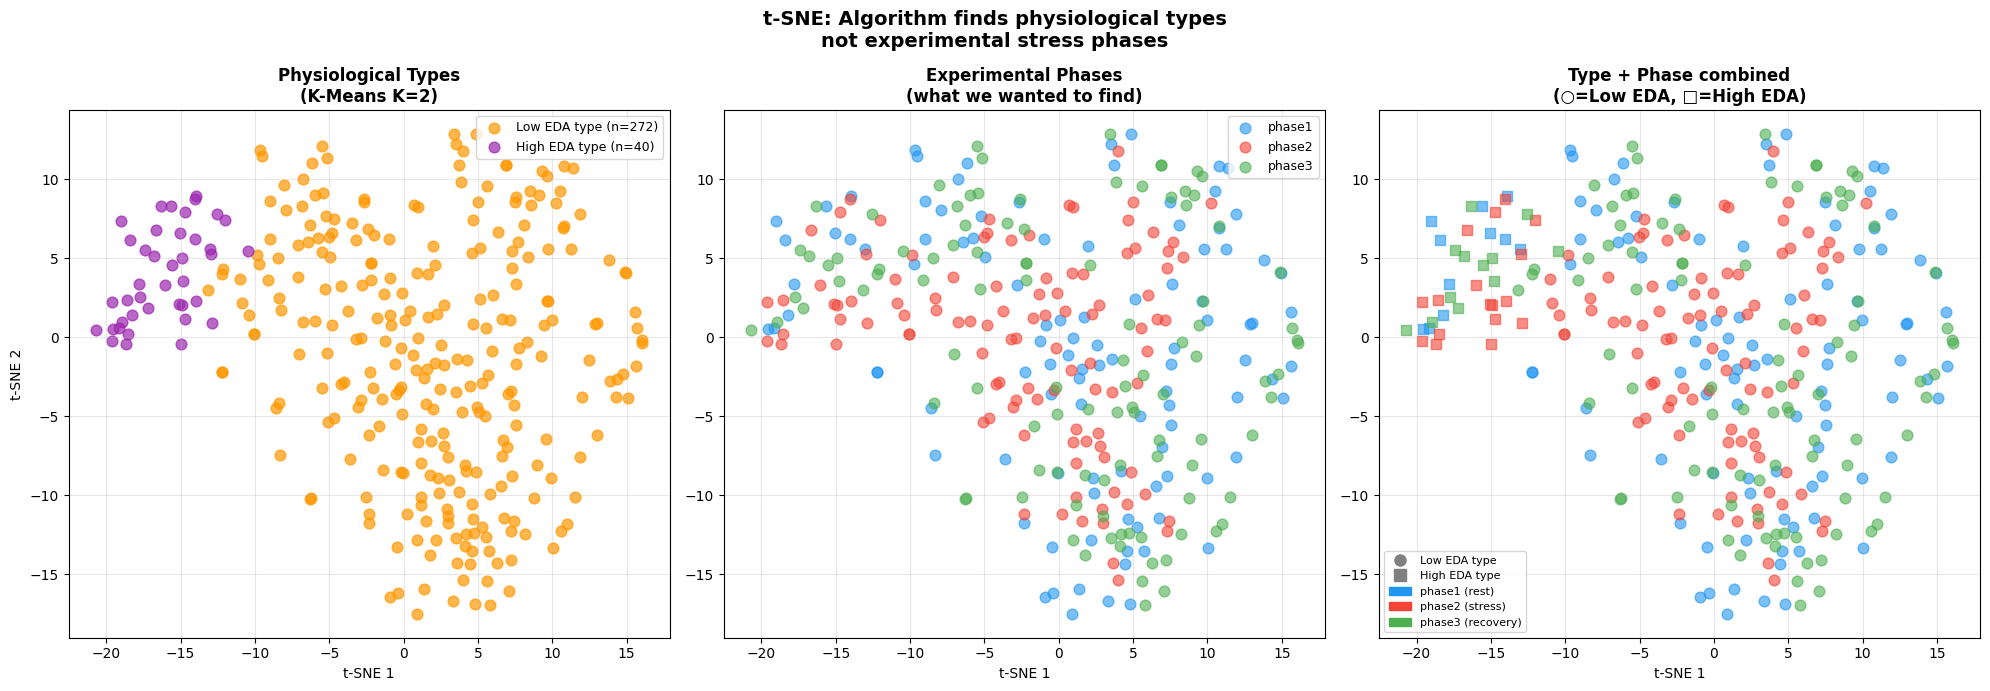

/tmp/ipykernel_5646/2730474931.py:111: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=['Low EDA\ntype', 'High EDA\ntype'],
/tmp/ipykernel_5646/2730474931.py:111: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=['Low EDA\ntype', 'High EDA\ntype'],
/tmp/ipykernel_5646/2730474931.py:111: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=['Low EDA\ntype', 'High EDA\ntype'],


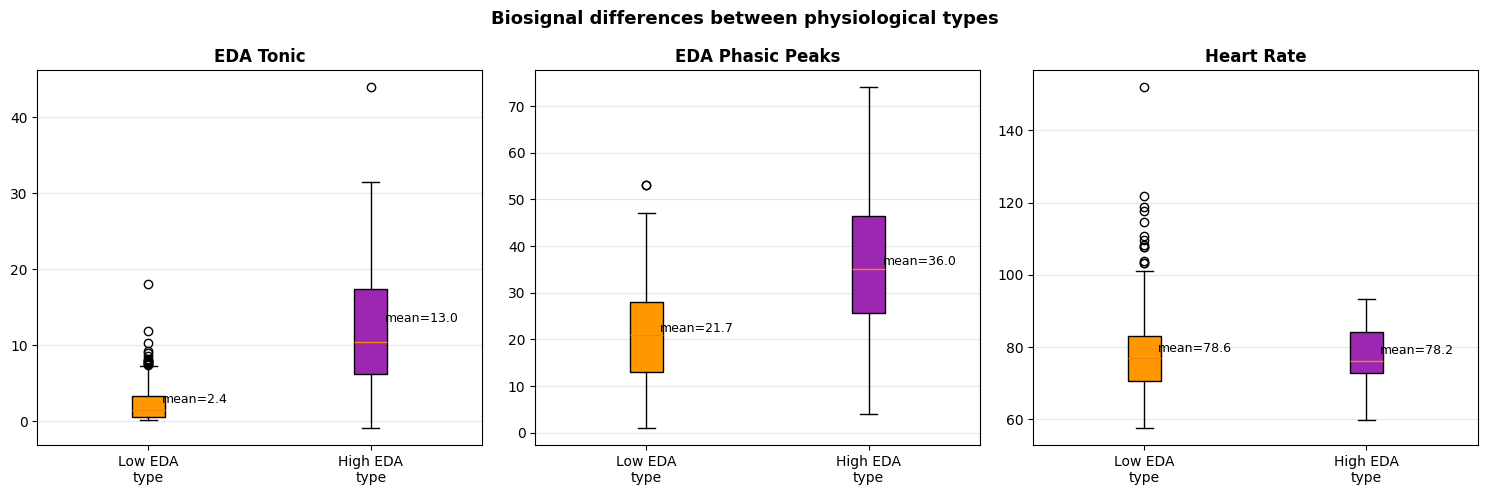

In [33]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np


km = KMeans(n_clusters=2, random_state=42, n_init=10)
cluster_labels = km.fit_predict(X_full_scaled)


df_temp = df.copy()
df_temp['cluster'] = cluster_labels


print("=== Average biosignals by clusters ===")
print(df_temp.groupby('cluster')[
    ['EDA_TD_T_Mean', 'EDA_TD_P_Peaks',
     'HR_TD_Mean', 'TEMP_TD_Mean']
].mean().round(2))

print("\n=== Participants by clusters ===")
participant_clusters = df_temp.groupby(
    ['Individual', 'cluster']
).size().unstack(fill_value=0)
print(participant_clusters)

participant_type = participant_clusters.idxmax(axis=1)
print("\n=== Type of every participant ===")
print(participant_type.value_counts())

fig, axes = plt.subplots(1, 3, figsize=(20, 7))

#clusters
cluster_colors = {0: '#FF9800', 1: '#9C27B0'}
cluster_names = {0: 'Low EDA type', 1: 'High EDA type'}

for c, color in cluster_colors.items():
    mask = cluster_labels == c
    n = mask.sum()
    axes[0].scatter(X_tsne[mask, 0], X_tsne[mask, 1],
                   c=color,
                   label=f'{cluster_names[c]} (n={n})',
                   alpha=0.7, s=60)

axes[0].set_title('Physiological Types\n(K-Means K=2)',
                  fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)
axes[0].set_xlabel('t-SNE 1')
axes[0].set_ylabel('t-SNE 2')

#phases
palette = {'phase1': '#2196F3',
           'phase2': '#F44336',
           'phase3': '#4CAF50'}

for phase, color in palette.items():
    mask = df['Phase'] == phase
    axes[1].scatter(X_tsne[mask, 0], X_tsne[mask, 1],
                   c=color, label=phase,
                   alpha=0.6, s=60)
axes[1].set_title('Experimental Phases\n(what we wanted to find)',
                  fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)
axes[1].set_xlabel('t-SNE 1')


markers = {0: 'o', 1: 's'}
for c, marker in markers.items():
    for phase, color in palette.items():
        mask = (cluster_labels == c) & (df['Phase'] == phase)
        axes[2].scatter(X_tsne[mask, 0], X_tsne[mask, 1],
                       c=color, marker=marker,
                       alpha=0.6, s=60,
                       label=f'{cluster_names[c][:3]}+{phase}'
                             if phase == 'phase1' else '')

#labels
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

legend_elements = [
    Line2D([0], [0], marker='o', color='grey',
           label='Low EDA type', markersize=8, linestyle='None'),
    Line2D([0], [0], marker='s', color='grey',
           label='High EDA type', markersize=8, linestyle='None'),
    Patch(color='#2196F3', label='phase1 (rest)'),
    Patch(color='#F44336', label='phase2 (stress)'),
    Patch(color='#4CAF50', label='phase3 (recovery)'),
]
axes[2].legend(handles=legend_elements, fontsize=8)
axes[2].set_title('Type + Phase combined\n(○=Low EDA, □=High EDA)',
                  fontweight='bold')
axes[2].grid(True, alpha=0.3)
axes[2].set_xlabel('t-SNE 1')

plt.suptitle('t-SNE: Algorithm finds physiological types\nnot experimental stress phases',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


fig, axes = plt.subplots(1, 3, figsize=(15, 5))

signals = ['EDA_TD_T_Mean', 'EDA_TD_P_Peaks', 'HR_TD_Mean']
titles = ['EDA Tonic', 'EDA Phasic Peaks', 'Heart Rate']

for ax, signal, title in zip(axes, signals, titles):
    data = [df_temp[df_temp['cluster'] == c][signal]
            for c in [0, 1]]
    bp = ax.boxplot(data, labels=['Low EDA\ntype', 'High EDA\ntype'],
                   patch_artist=True)
    bp['boxes'][0].set_facecolor('#FF9800')
    bp['boxes'][1].set_facecolor('#9C27B0')
    ax.set_title(title, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')


    for i, d in enumerate(data):
        ax.annotate(f'mean={d.mean():.1f}',
                   xy=(i+1, d.mean()),
                   xytext=(10, 0),
                   textcoords='offset points',
                   fontsize=9, color='black')

plt.suptitle('Biosignal differences between physiological types',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


/tmp/ipykernel_5646/2259934276.py:141: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o-" (-> marker='o'). The keyword argument will take precedence.
  axes[2].plot(centers_x, centers_y,


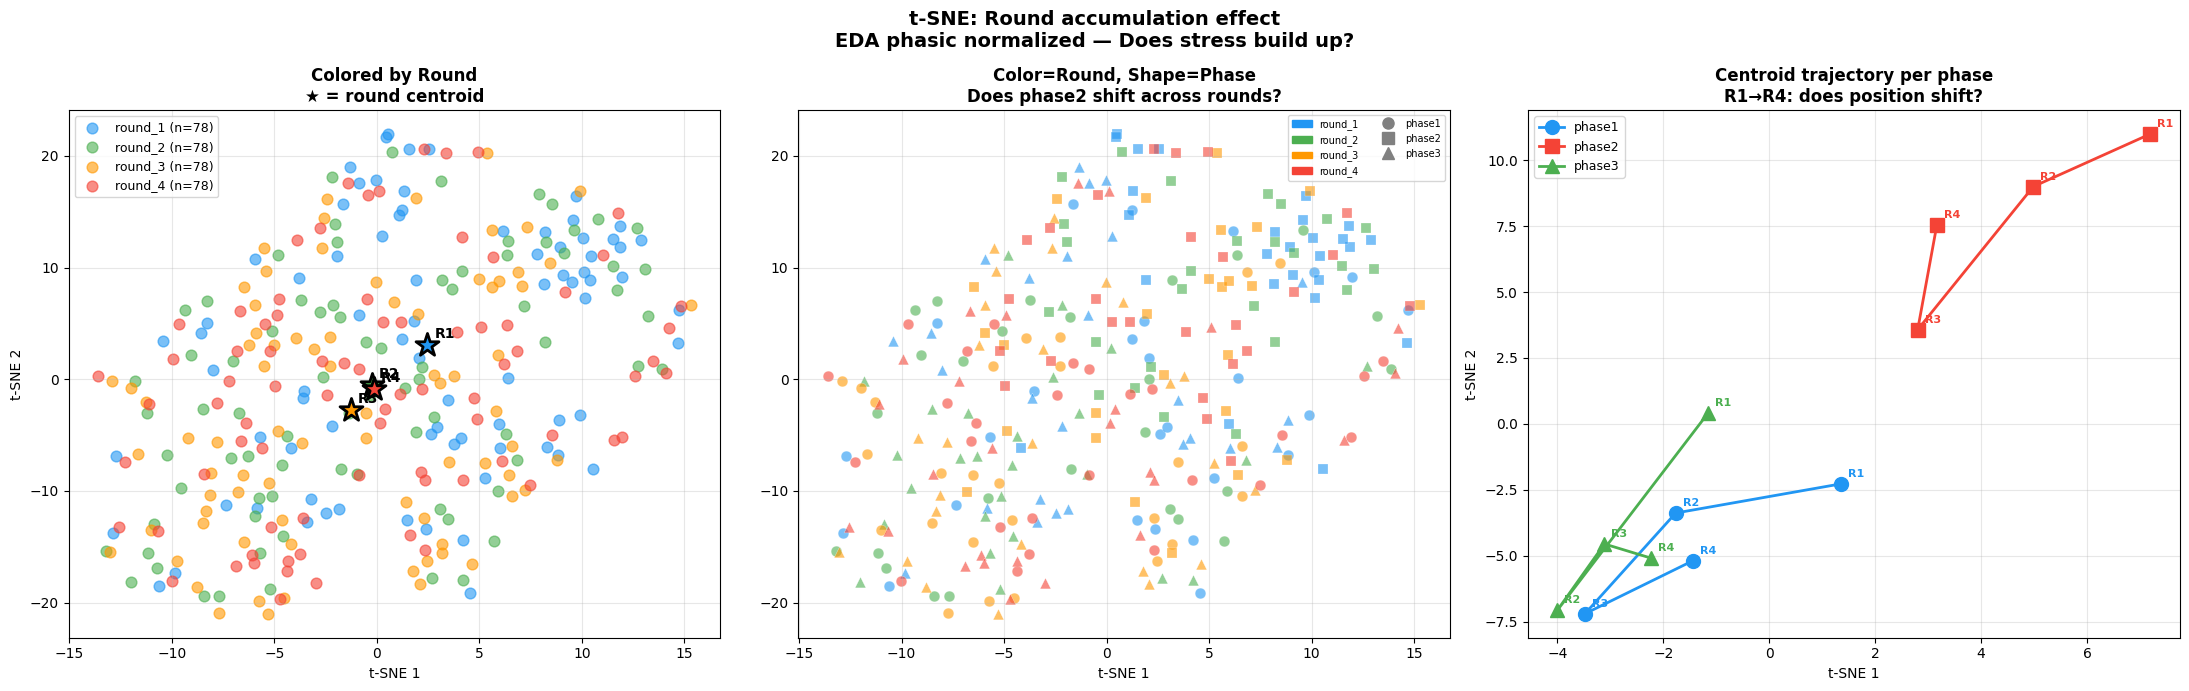

In [26]:
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np

eda_p_cols = [
    'EDA_TD_P_Peaks', 'EDA_TD_P_Mean',
    'EDA_TD_P_std', 'EDA_TD_P_RT',
    'EDA_TD_P_ReT'
]

X_eda = df[eda_p_cols].fillna(
    df[eda_p_cols].median()
).astype(float)

X_norm = X_eda.copy()
for ind in df['Individual'].unique():
    mask = df['Individual'] == ind
    X_norm.loc[mask] = (
        X_eda.loc[mask] - X_eda.loc[mask].mean()
    )

X_sc = StandardScaler().fit_transform(X_norm)

tsne = TSNE(n_components=2, perplexity=30,
            random_state=42, max_iter=1000)
X_tsne = tsne.fit_transform(X_sc)


round_palette = {
    'round_1': '#2196F3',  #
    'round_2': '#4CAF50',  #
    'round_3': '#FF9800',  #
    'round_4': '#F44336',  #
}

phase_markers = {
    'phase1': 'o',
    'phase2': 's',
    'phase3': '^'
}

fig, axes = plt.subplots(1, 3, figsize=(22, 7))


for round_, color in round_palette.items():
    mask = df['Round'] == round_
    n = mask.sum()
    axes[0].scatter(
        X_tsne[mask, 0], X_tsne[mask, 1],
        c=color, label=f'{round_} (n={n})',
        alpha=0.6, s=60
    )


for round_, color in round_palette.items():
    mask = df['Round'].values == round_
    center = X_tsne[mask].mean(axis=0)
    axes[0].scatter(
        center[0], center[1],
        c=color, s=300,
        edgecolors='black',
        linewidth=2, zorder=5,
        marker='*'
    )
    axes[0].annotate(
        round_.replace('round_', 'R'),
        xy=(center[0], center[1]),
        xytext=(5, 5),
        textcoords='offset points',
        fontsize=10, fontweight='bold'
    )

axes[0].set_title('Colored by Round\n'
                  '★ = round centroid',
                  fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)
axes[0].set_xlabel('t-SNE 1')
axes[0].set_ylabel('t-SNE 2')


for round_, color in round_palette.items():
    for phase, marker in phase_markers.items():
        mask = ((df['Round'] == round_) &
                (df['Phase'] == phase))
        axes[1].scatter(
            X_tsne[mask, 0], X_tsne[mask, 1],
            c=color, marker=marker,
            alpha=0.6, s=60,
            edgecolors='white', linewidth=0.3
        )

from matplotlib.patches import Patch
from matplotlib.lines import Line2D

legend_rounds = [
    Patch(color=c, label=r)
    for r, c in round_palette.items()
]
legend_phases = [
    Line2D([0], [0], marker='o', color='grey',
           label='phase1', markersize=8,
           linestyle='None'),
    Line2D([0], [0], marker='s', color='grey',
           label='phase2', markersize=8,
           linestyle='None'),
    Line2D([0], [0], marker='^', color='grey',
           label='phase3', markersize=8,
           linestyle='None'),
]
axes[1].legend(
    handles=legend_rounds + legend_phases,
    fontsize=7, ncol=2
)
axes[1].set_title('Color=Round, Shape=Phase\n'
                  'Does phase2 shift across rounds?',
                  fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].set_xlabel('t-SNE 1')


round_order = ['round_1', 'round_2',
               'round_3', 'round_4']

for phase, marker in phase_markers.items():
    centers_x = []
    centers_y = []

    for round_ in round_order:
        mask = ((df['Round'] == round_) &
                (df['Phase'] == phase))
        center = X_tsne[mask].mean(axis=0)
        centers_x.append(center[0])
        centers_y.append(center[1])

    color = {'phase1': '#2196F3',
             'phase2': '#F44336',
             'phase3': '#4CAF50'}[phase]

    axes[2].plot(centers_x, centers_y,
                'o-', color=color,
                linewidth=2, markersize=10,
                label=phase, marker=marker)


    for i, (x, y) in enumerate(
        zip(centers_x, centers_y)
    ):
        axes[2].annotate(
            f'R{i+1}',
            xy=(x, y),
            xytext=(5, 5),
            textcoords='offset points',
            fontsize=8, color=color,
            fontweight='bold'
        )

axes[2].set_title('Centroid trajectory per phase\n'
                  'R1→R4: does position shift?',
                  fontweight='bold')
axes[2].legend(fontsize=9)
axes[2].grid(True, alpha=0.3)
axes[2].set_xlabel('t-SNE 1')
axes[2].set_ylabel('t-SNE 2')

plt.suptitle('t-SNE: Round accumulation effect\n'
             'EDA phasic normalized — Does stress build up?',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
